<a href="https://colab.research.google.com/github/arafatro/IntroToDS/blob/main/Practice%20Materials/Week%202/DS_Practice_Univariate_Stats_Plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Data Science
## Practice Session — Univariate Descriptive Statistics & Plots
**Eötvös Loránd University (ELTE) · Faculty of Informatics**

---
**Instructor:** Arafat Md Easin  
**Goal:** By the end of this session you will be able to:
- Compute and interpret descriptive statistics for a single variable
- Distinguish between measures of central tendency, spread, and shape
- Choose and produce the correct plot for any variable type
- Read and critically interpret what each plot tells you

> **Tip:** Run each cell with `Shift + Enter` and read the comments carefully before moving on.

---
## Part 0 — Setup & Dataset

In [3]:
!pip install ucimlrepo -q

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# Style settings — applied once for the whole notebook
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Load dataset
student_performance = fetch_ucirepo(id=320)
X = student_performance.data.features
y = student_performance.data.targets
df = pd.concat([X, y], axis=1)

print("Dataset loaded:", df.shape)
df.head(3)

Dataset loaded: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12


---
## Part 1 — Measures of Central Tendency

Central tendency answers: **"Where is the centre of the data?"**

| Measure | Formula | Best used when |
|---|---|---|
| **Mean** | sum / n | No extreme outliers, symmetric data |
| **Median** | middle value | Skewed data or outliers present |
| **Mode** | most frequent value | Categorical data or discrete counts |

In [5]:
# ── 1.1  Mean, Median, Mode for final grade G3 ────────────────────────

col = "G3"

mean   = df[col].mean()
median = df[col].median()
mode   = df[col].mode()[0]   # mode() returns a Series; take first value

print(f"Column : {col}")
print(f"Mean   : {mean:.2f}")
print(f"Median : {median:.2f}")
print(f"Mode   : {mode}")
print()
print("Interpretation:")
print(f"  Mean ≈ Median ({mean:.1f} ≈ {median:.1f}) → distribution is roughly symmetric")

Column : G3
Mean   : 11.91
Median : 12.00
Mode   : 11

Interpretation:
  Mean ≈ Median (11.9 ≈ 12.0) → distribution is roughly symmetric


In [6]:
# ── 1.2  Effect of outliers on Mean vs Median ─────────────────────────
# A key reason to always check both:

example = pd.Series([10, 11, 12, 13, 14, 100])   # 100 is an outlier

print("Data  :", example.tolist())
print(f"Mean  : {example.mean():.2f}   ← pulled up by the outlier")
print(f"Median: {example.median():.2f}  ← resistant to the outlier")

Data  : [10, 11, 12, 13, 14, 100]
Mean  : 26.67   ← pulled up by the outlier
Median: 12.50  ← resistant to the outlier


In [7]:
# ── 1.3  Mode for a categorical column ───────────────────────────────

print("Most common guardian:", df["guardian"].mode()[0])
print()
print("Full frequency table:")
print(df["guardian"].value_counts())

Most common guardian: mother

Full frequency table:
guardian
mother    455
father    153
other      41
Name: count, dtype: int64


### Exercise 1
Compute the mean, median, and mode for the column `absences`.  
Is the mean or median more representative here? Why?
```python
# Your code here
```

In [ ]:
# Your answer here


---
## Part 2 — Measures of Spread

Spread answers: **"How much do values vary around the centre?"**

| Measure | Meaning |
|---|---|
| **Range** | max − min |
| **Variance** | average squared deviation from mean |
| **Standard Deviation (std)** | square root of variance — same unit as data |
| **IQR** | Q3 − Q1 — range of the middle 50% — robust to outliers |
| **Quartiles (Q1, Q2, Q3)** | values at 25th, 50th, 75th percentile |

In [8]:
# ── 2.1  Range, Variance, Std, IQR for G3 ────────────────────────────

col = "G3"

range_val = df[col].max() - df[col].min()
variance  = df[col].var()
std       = df[col].std()
q1        = df[col].quantile(0.25)
q3        = df[col].quantile(0.75)
iqr       = q3 - q1

print(f"Column : {col}")
print(f"Min    : {df[col].min()}")
print(f"Max    : {df[col].max()}")
print(f"Range  : {range_val}")
print(f"Variance: {variance:.2f}")
print(f"Std Dev : {std:.2f}")
print(f"Q1     : {q1}")
print(f"Q3     : {q3}")
print(f"IQR    : {iqr}")

Column : G3
Min    : 0
Max    : 19
Range  : 19
Variance: 10.44
Std Dev : 3.23
Q1     : 10.0
Q3     : 14.0
IQR    : 4.0


In [9]:
# ── 2.2  The all-in-one: describe() ───────────────────────────────────
# .describe() gives all key statistics at once

print("Summary statistics for all numerical columns:")
display(df.describe().T.round(2))   # .T transposes for easier reading

Summary statistics for all numerical columns:


,count,mean,std,min,25%,50%,75%,max
age,649.0,16.74,1.22,15.0,16.0,17.0,18.0,22.0
Medu,649.0,2.51,1.13,0.0,2.0,2.0,4.0,4.0
Fedu,649.0,2.31,1.10,0.0,1.0,2.0,3.0,4.0
traveltime,649.0,1.57,0.75,1.0,1.0,1.0,2.0,4.0
studytime,649.0,1.93,0.83,1.0,1.0,2.0,2.0,4.0
failures,649.0,0.22,0.59,0.0,0.0,0.0,0.0,3.0
famrel,649.0,3.93,0.96,1.0,4.0,4.0,5.0,5.0
freetime,649.0,3.18,1.05,1.0,3.0,3.0,4.0,5.0
goout,649.0,3.18,1.18,1.0,2.0,3.0,4.0,5.0
Dalc,649.0,1.50,0.92,1.0,1.0,1.0,2.0,5.0


In [10]:
# ── 2.3  Comparing spread across groups ──────────────────────────────
# How much does G3 vary between male and female students?

print("G3 statistics by sex:")
display(
    df.groupby("sex")["G3"]
    .agg(["mean", "median", "std", "min", "max"])
    .round(2)
)

G3 statistics by sex:


,mean,median,std,min,max
sex,,,,,
F,12.25,12.0,3.12,0,19
M,11.41,11.0,3.32,0,19


### Exercise 2
1. Compute the IQR for `age`.
2. Identify any values that fall outside `Q1 − 1.5×IQR` or `Q3 + 1.5×IQR` — these are considered outliers by the Tukey rule.
```python
# Hint:
# lower = q1 - 1.5 * iqr
# upper = q3 + 1.5 * iqr
# df[(df["age"] < lower) | (df["age"] > upper)]
```

In [ ]:
# Your answer here


---
## Part 3 — Measures of Shape

Shape answers: **"How is the data distributed?"**

| Measure | What it tells you |
|---|---|
| **Skewness** | asymmetry of the distribution (0 = symmetric) |
| **Kurtosis** | heaviness of the tails (0 = normal-like) |

```
Skewness > 0  →  Right-skewed (long right tail, mean > median)
Skewness < 0  →  Left-skewed  (long left tail,  mean < median)
Skewness ≈ 0  →  Symmetric
```

In [11]:
# ── 3.1  Skewness and Kurtosis ────────────────────────────────────────

num_cols = df.select_dtypes(include=["int64", "float64"]).columns

shape_stats = pd.DataFrame({
    "Skewness" : df[num_cols].skew().round(3),
    "Kurtosis" : df[num_cols].kurt().round(3)
})

shape_stats["Skew Direction"] = shape_stats["Skewness"].apply(
    lambda s: "Right-skewed" if s > 0.5 else ("Left-skewed" if s < -0.5 else "Roughly symmetric")
)

display(shape_stats)

,Skewness,Kurtosis,Skew Direction
age,0.417,0.072,Roughly symmetric
Medu,-0.030,-1.261,Roughly symmetric
Fedu,0.215,-1.109,Roughly symmetric
traveltime,1.248,1.109,Right-skewed
studytime,0.700,0.038,Right-skewed
failures,3.093,9.824,Right-skewed
famrel,-1.106,1.349,Left-skewed
freetime,-0.181,-0.397,Roughly symmetric
goout,-0.009,-0.865,Roughly symmetric
Dalc,2.142,4.349,Right-skewed


---
## Part 4 — Univariate Plots

The right plot depends on the **type of variable**:

| Variable Type | Best Plot |
|---|---|
| Continuous numerical | Histogram, KDE, Boxplot |
| Discrete numerical | Bar chart, Histogram |
| Categorical / Binary | Bar chart, Pie chart |
| Any single variable | `describe()` first, then plot |

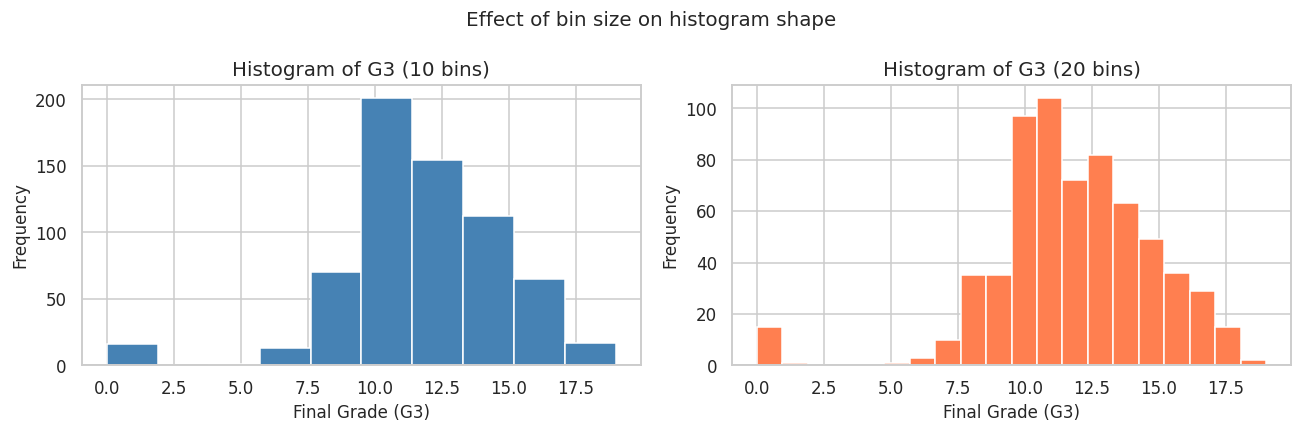

Observation: More bins reveal finer structure but can be noisy.


In [12]:
# ── 4.1  Histogram — distribution of a continuous variable ───────────
# Shows how values are distributed across bins.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Default bins
axes[0].hist(df["G3"], bins=10, color="steelblue", edgecolor="white")
axes[0].set_title("Histogram of G3 (10 bins)")
axes[0].set_xlabel("Final Grade (G3)")
axes[0].set_ylabel("Frequency")

# More bins → finer detail
axes[1].hist(df["G3"], bins=20, color="coral", edgecolor="white")
axes[1].set_title("Histogram of G3 (20 bins)")
axes[1].set_xlabel("Final Grade (G3)")
axes[1].set_ylabel("Frequency")

plt.suptitle("Effect of bin size on histogram shape", fontsize=13)
plt.tight_layout()
plt.show()

print("Observation: More bins reveal finer structure but can be noisy.")

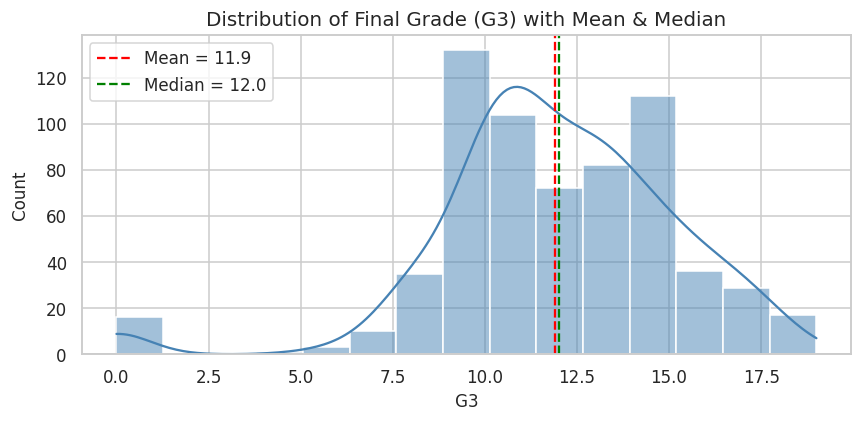

Skewness: -0.913 → Left-skewed


In [13]:
# ── 4.2  KDE plot — smooth version of a histogram ────────────────────
# KDE = Kernel Density Estimate. Estimates the probability density.

fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(df["G3"], kde=True, bins=15, color="steelblue", ax=ax)

# Add vertical lines for mean and median
ax.axvline(df["G3"].mean(),   color="red",    linestyle="--", label=f"Mean = {df['G3'].mean():.1f}")
ax.axvline(df["G3"].median(), color="green",  linestyle="--", label=f"Median = {df['G3'].median():.1f}")

ax.set_title("Distribution of Final Grade (G3) with Mean & Median")
ax.set_xlabel("G3")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Skewness: {df['G3'].skew():.3f} → ", end="")
print("Left-skewed" if df['G3'].skew() < -0.5 else "Right-skewed" if df['G3'].skew() > 0.5 else "Roughly symmetric")

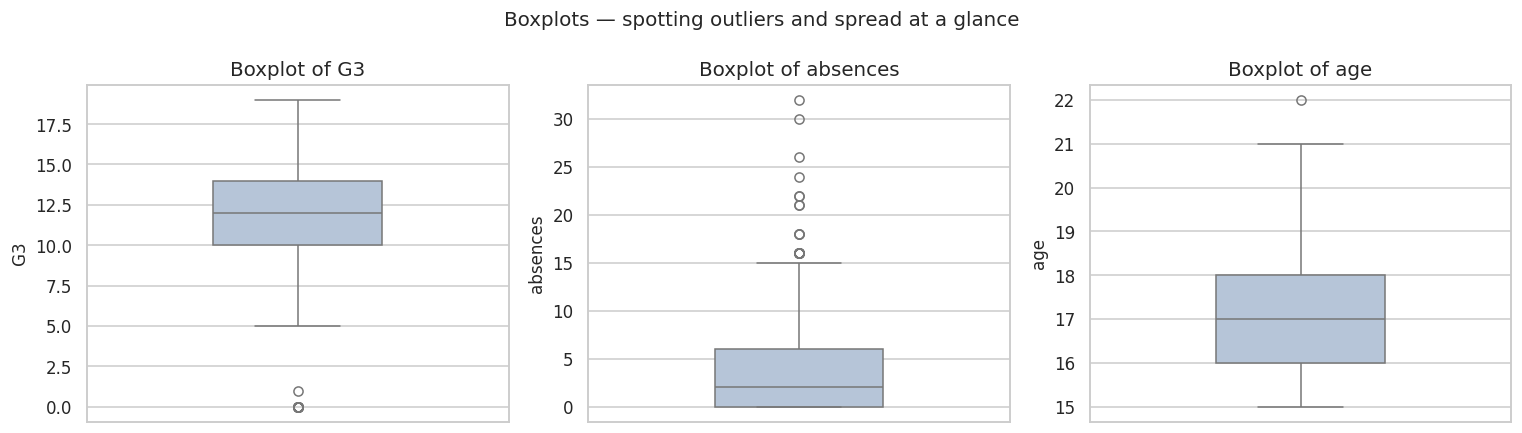

Notice: 'absences' has many high outliers → right-skewed distribution.


In [14]:
# ── 4.3  Boxplot — five-number summary in one plot ────────────────────
#
#   |---[ Q1  |  median  |  Q3 ]---|   o  o  (outliers)
#   whisker  box                whisker
#
# Box     = IQR (middle 50% of data)
# Whiskers = extend to 1.5 × IQR from Q1/Q3
# Dots    = outliers beyond the whiskers

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ["G3", "absences", "age"]):
    sns.boxplot(y=df[col], ax=ax, color="lightsteelblue", width=0.4)
    ax.set_title(f"Boxplot of {col}")
    ax.set_ylabel(col)

plt.suptitle("Boxplots — spotting outliers and spread at a glance", fontsize=13)
plt.tight_layout()
plt.show()

print("Notice: 'absences' has many high outliers → right-skewed distribution.")

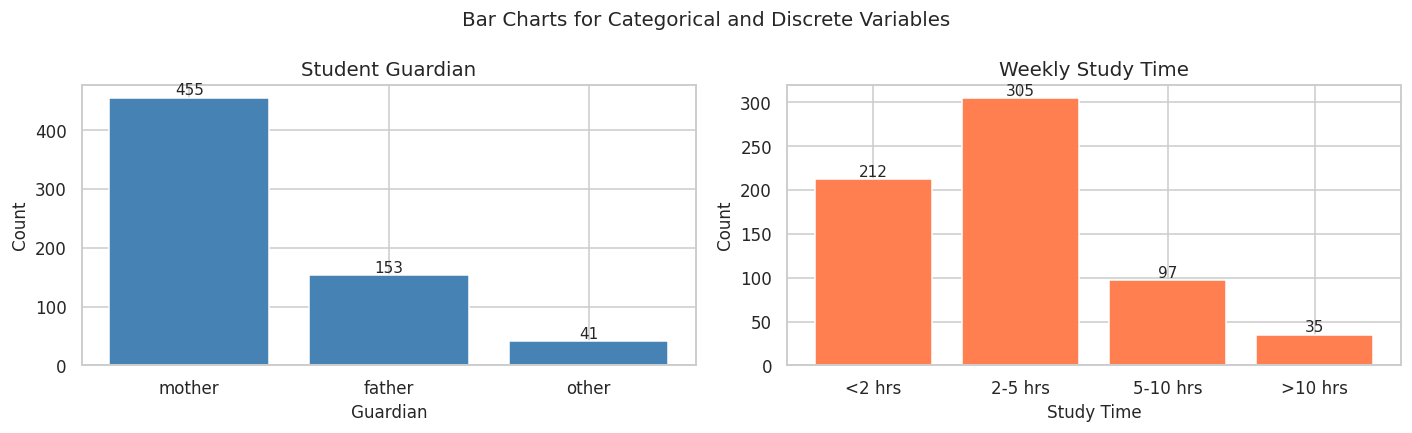

In [15]:
# ── 4.4  Bar chart — frequency of a categorical variable ─────────────
# Use for categorical or discrete variables with few unique values.

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Categorical: guardian
guardian_counts = df["guardian"].value_counts()
axes[0].bar(guardian_counts.index, guardian_counts.values, color="steelblue", edgecolor="white")
axes[0].set_title("Student Guardian")
axes[0].set_xlabel("Guardian")
axes[0].set_ylabel("Count")
for i, v in enumerate(guardian_counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=10)

# Discrete: study time
study_map = {1: "<2 hrs", 2: "2-5 hrs", 3: "5-10 hrs", 4: ">10 hrs"}
study_counts = df["studytime"].value_counts().sort_index()
study_counts.index = study_counts.index.map(study_map)
axes[1].bar(study_counts.index, study_counts.values, color="coral", edgecolor="white")
axes[1].set_title("Weekly Study Time")
axes[1].set_xlabel("Study Time")
axes[1].set_ylabel("Count")
for i, v in enumerate(study_counts.values):
    axes[1].text(i, v + 3, str(v), ha="center", fontsize=10)

plt.suptitle("Bar Charts for Categorical and Discrete Variables", fontsize=13)
plt.tight_layout()
plt.show()

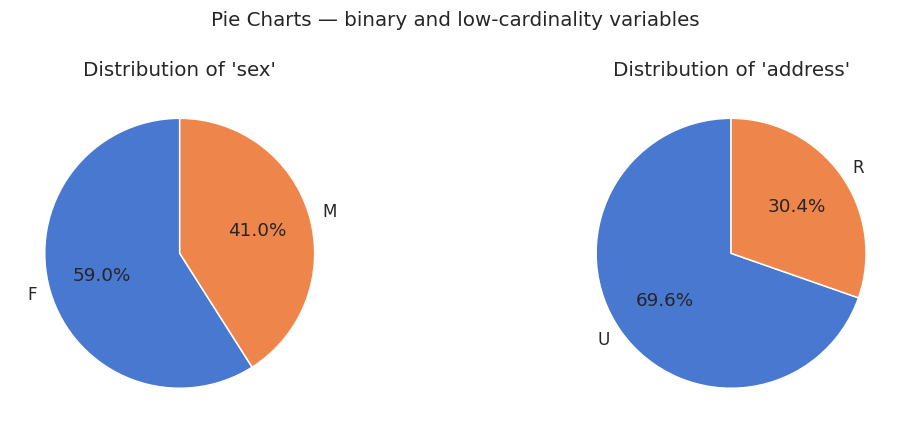

In [16]:
# ── 4.5  Pie chart — proportion of a binary variable ──────────────────
# Best for 2–4 categories only. Avoid for many categories.

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col in zip(axes, ["sex", "address"]):
    counts = df[col].value_counts()
    ax.pie(
        counts.values,
        labels=counts.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=sns.color_palette("muted", len(counts))
    )
    ax.set_title(f"Distribution of '{col}'")

plt.suptitle("Pie Charts — binary and low-cardinality variables", fontsize=13)
plt.tight_layout()
plt.show()

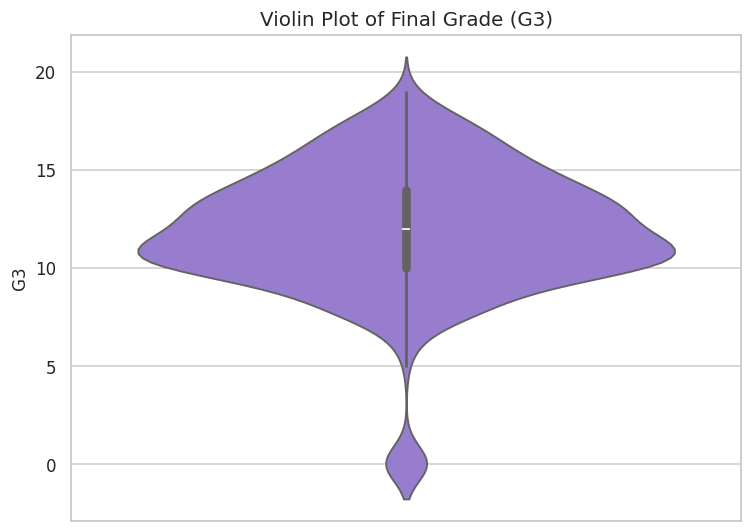

The wide middle section shows where most students scored.
The inner box is the IQR — same as a standard boxplot.


In [17]:
# ── 4.6  Violin plot — distribution shape + spread in one ─────────────
# A violin plot combines a KDE (shape) with a boxplot (spread).
# Width = density of values at that point.

fig, ax = plt.subplots(figsize=(7, 5))

sns.violinplot(y=df["G3"], ax=ax, color="mediumpurple", inner="box")
ax.set_title("Violin Plot of Final Grade (G3)")
ax.set_ylabel("G3")
plt.tight_layout()
plt.show()

print("The wide middle section shows where most students scored.")
print("The inner box is the IQR — same as a standard boxplot.")

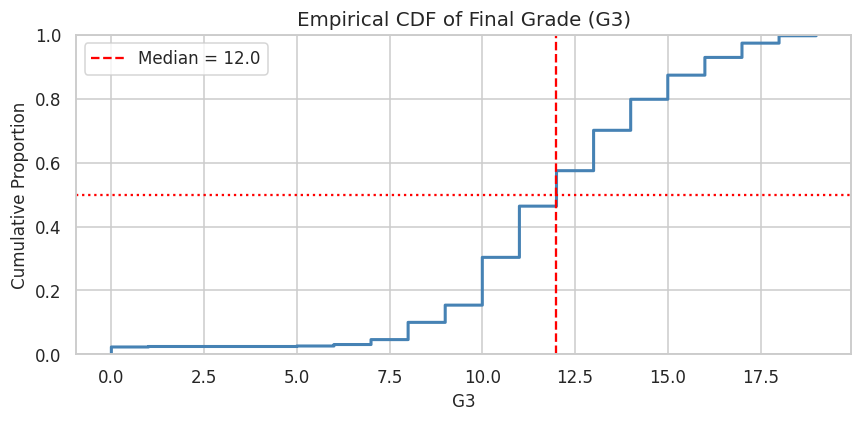

Read: 50% of students scored at or below 12.0


In [18]:
# ── 4.7  Cumulative Distribution Function (CDF) ───────────────────────
# CDF(x) = probability that a value is ≤ x
# Useful for reading off percentiles directly from the plot.

fig, ax = plt.subplots(figsize=(8, 4))

sns.ecdfplot(df["G3"], ax=ax, color="steelblue", linewidth=2)

# Annotate the median (50th percentile)
median_g3 = df["G3"].median()
ax.axvline(median_g3, color="red", linestyle="--", label=f"Median = {median_g3}")
ax.axhline(0.5,        color="red", linestyle=":")

ax.set_title("Empirical CDF of Final Grade (G3)")
ax.set_xlabel("G3")
ax.set_ylabel("Cumulative Proportion")
ax.legend()
plt.tight_layout()
plt.show()

print("Read: 50% of students scored at or below", median_g3)

### Exercise 3
For the column `absences`:
1. Plot a **histogram** with 15 bins
2. Plot a **boxplot** and identify the outliers
3. Print the skewness and write one sentence interpreting it

```python
# Your code here
```

In [ ]:
# Your answer here


---
## Part 5 — Full Univariate Profile of a Variable
Bringing everything together into a single diagnostic panel — this is what you do at the start of any real analysis.

  Univariate Profile: G3
  Count    : 649
  Missing  : 0
  Mean     : 11.906
  Median   : 12.000
  Mode     : 11
  Std Dev  : 3.231
  Variance : 10.437
  Min      : 0
  Q1 (25%) : 10.0
  Q3 (75%) : 14.0
  Max      : 19
  IQR      : 4.0
  Skewness : -0.913
  Kurtosis : 2.712



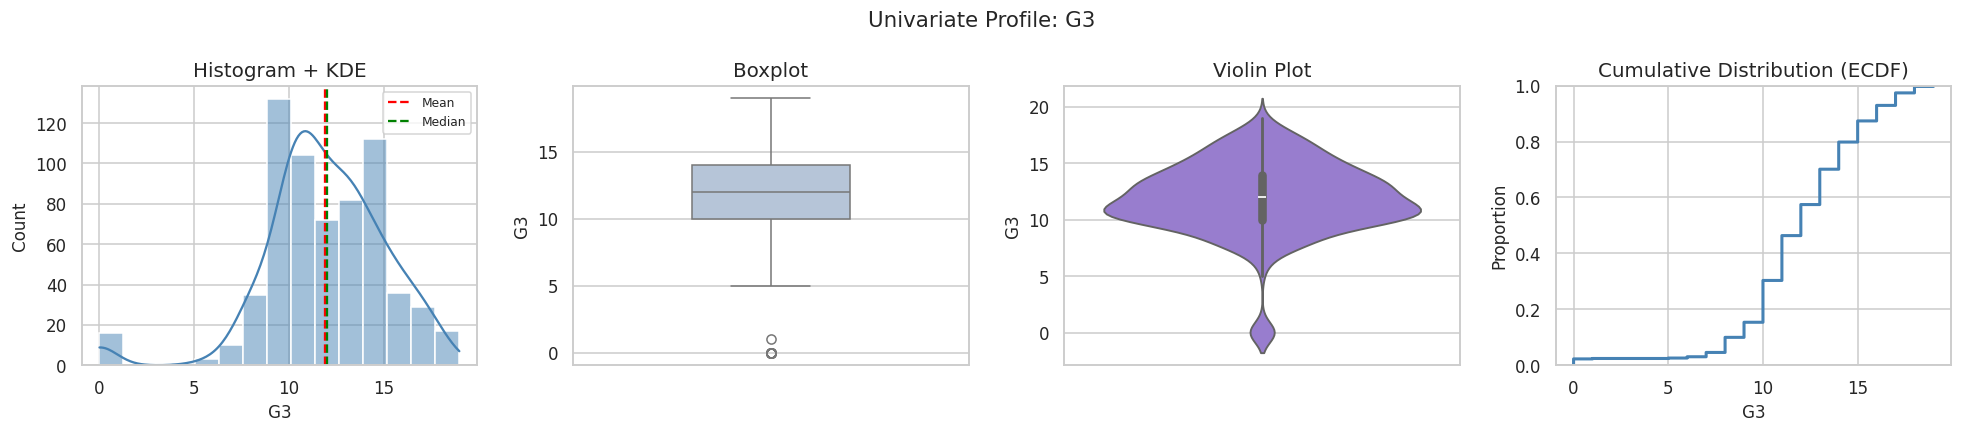

In [19]:
# ── 5.1  Univariate profile function ─────────────────────────────────
# Reusable function: pass any numerical column and get a full summary.

def univariate_profile(dataframe, column):
    """Print stats and plot a 4-panel diagnostic for one numerical column."""

    series = dataframe[column].dropna()

    # ── Stats ──
    print(f"{'='*50}")
    print(f"  Univariate Profile: {column}")
    print(f"{'='*50}")
    print(f"  Count    : {len(series)}")
    print(f"  Missing  : {dataframe[column].isnull().sum()}")
    print(f"  Mean     : {series.mean():.3f}")
    print(f"  Median   : {series.median():.3f}")
    print(f"  Mode     : {series.mode()[0]}")
    print(f"  Std Dev  : {series.std():.3f}")
    print(f"  Variance : {series.var():.3f}")
    print(f"  Min      : {series.min()}")
    print(f"  Q1 (25%) : {series.quantile(0.25)}")
    print(f"  Q3 (75%) : {series.quantile(0.75)}")
    print(f"  Max      : {series.max()}")
    print(f"  IQR      : {series.quantile(0.75) - series.quantile(0.25)}")
    print(f"  Skewness : {series.skew():.3f}")
    print(f"  Kurtosis : {series.kurt():.3f}")
    print()

    # ── Plots ──
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(f"Univariate Profile: {column}", fontsize=14)

    # Histogram + KDE
    sns.histplot(series, kde=True, bins=15, ax=axes[0], color="steelblue")
    axes[0].axvline(series.mean(),   color="red",   linestyle="--", label="Mean")
    axes[0].axvline(series.median(), color="green", linestyle="--", label="Median")
    axes[0].set_title("Histogram + KDE")
    axes[0].legend(fontsize=8)

    # Boxplot
    sns.boxplot(y=series, ax=axes[1], color="lightsteelblue", width=0.4)
    axes[1].set_title("Boxplot")

    # Violin
    sns.violinplot(y=series, ax=axes[2], color="mediumpurple", inner="box")
    axes[2].set_title("Violin Plot")

    # ECDF
    sns.ecdfplot(series, ax=axes[3], color="steelblue", linewidth=2)
    axes[3].set_title("Cumulative Distribution (ECDF)")

    plt.tight_layout()
    plt.show()


# Run for final grade G3
univariate_profile(df, "G3")

In [ ]:
# Try on a right-skewed column
univariate_profile(df, "absences")

---
## Part 6 — Choosing the Right Plot

A quick reference you should keep in mind:

| Question | Variable Type | Plot |
|---|---|---|
| How are values distributed? | Continuous | Histogram, KDE |
| Where is the centre & spread? | Continuous | Boxplot |
| Are there outliers? | Continuous | Boxplot |
| What is the shape? | Continuous | Histogram, Violin |
| What % of values are ≤ x? | Any numerical | ECDF |
| How frequent is each category? | Categorical | Bar chart |
| What is the proportion? | Binary / low-cardinality | Pie chart |

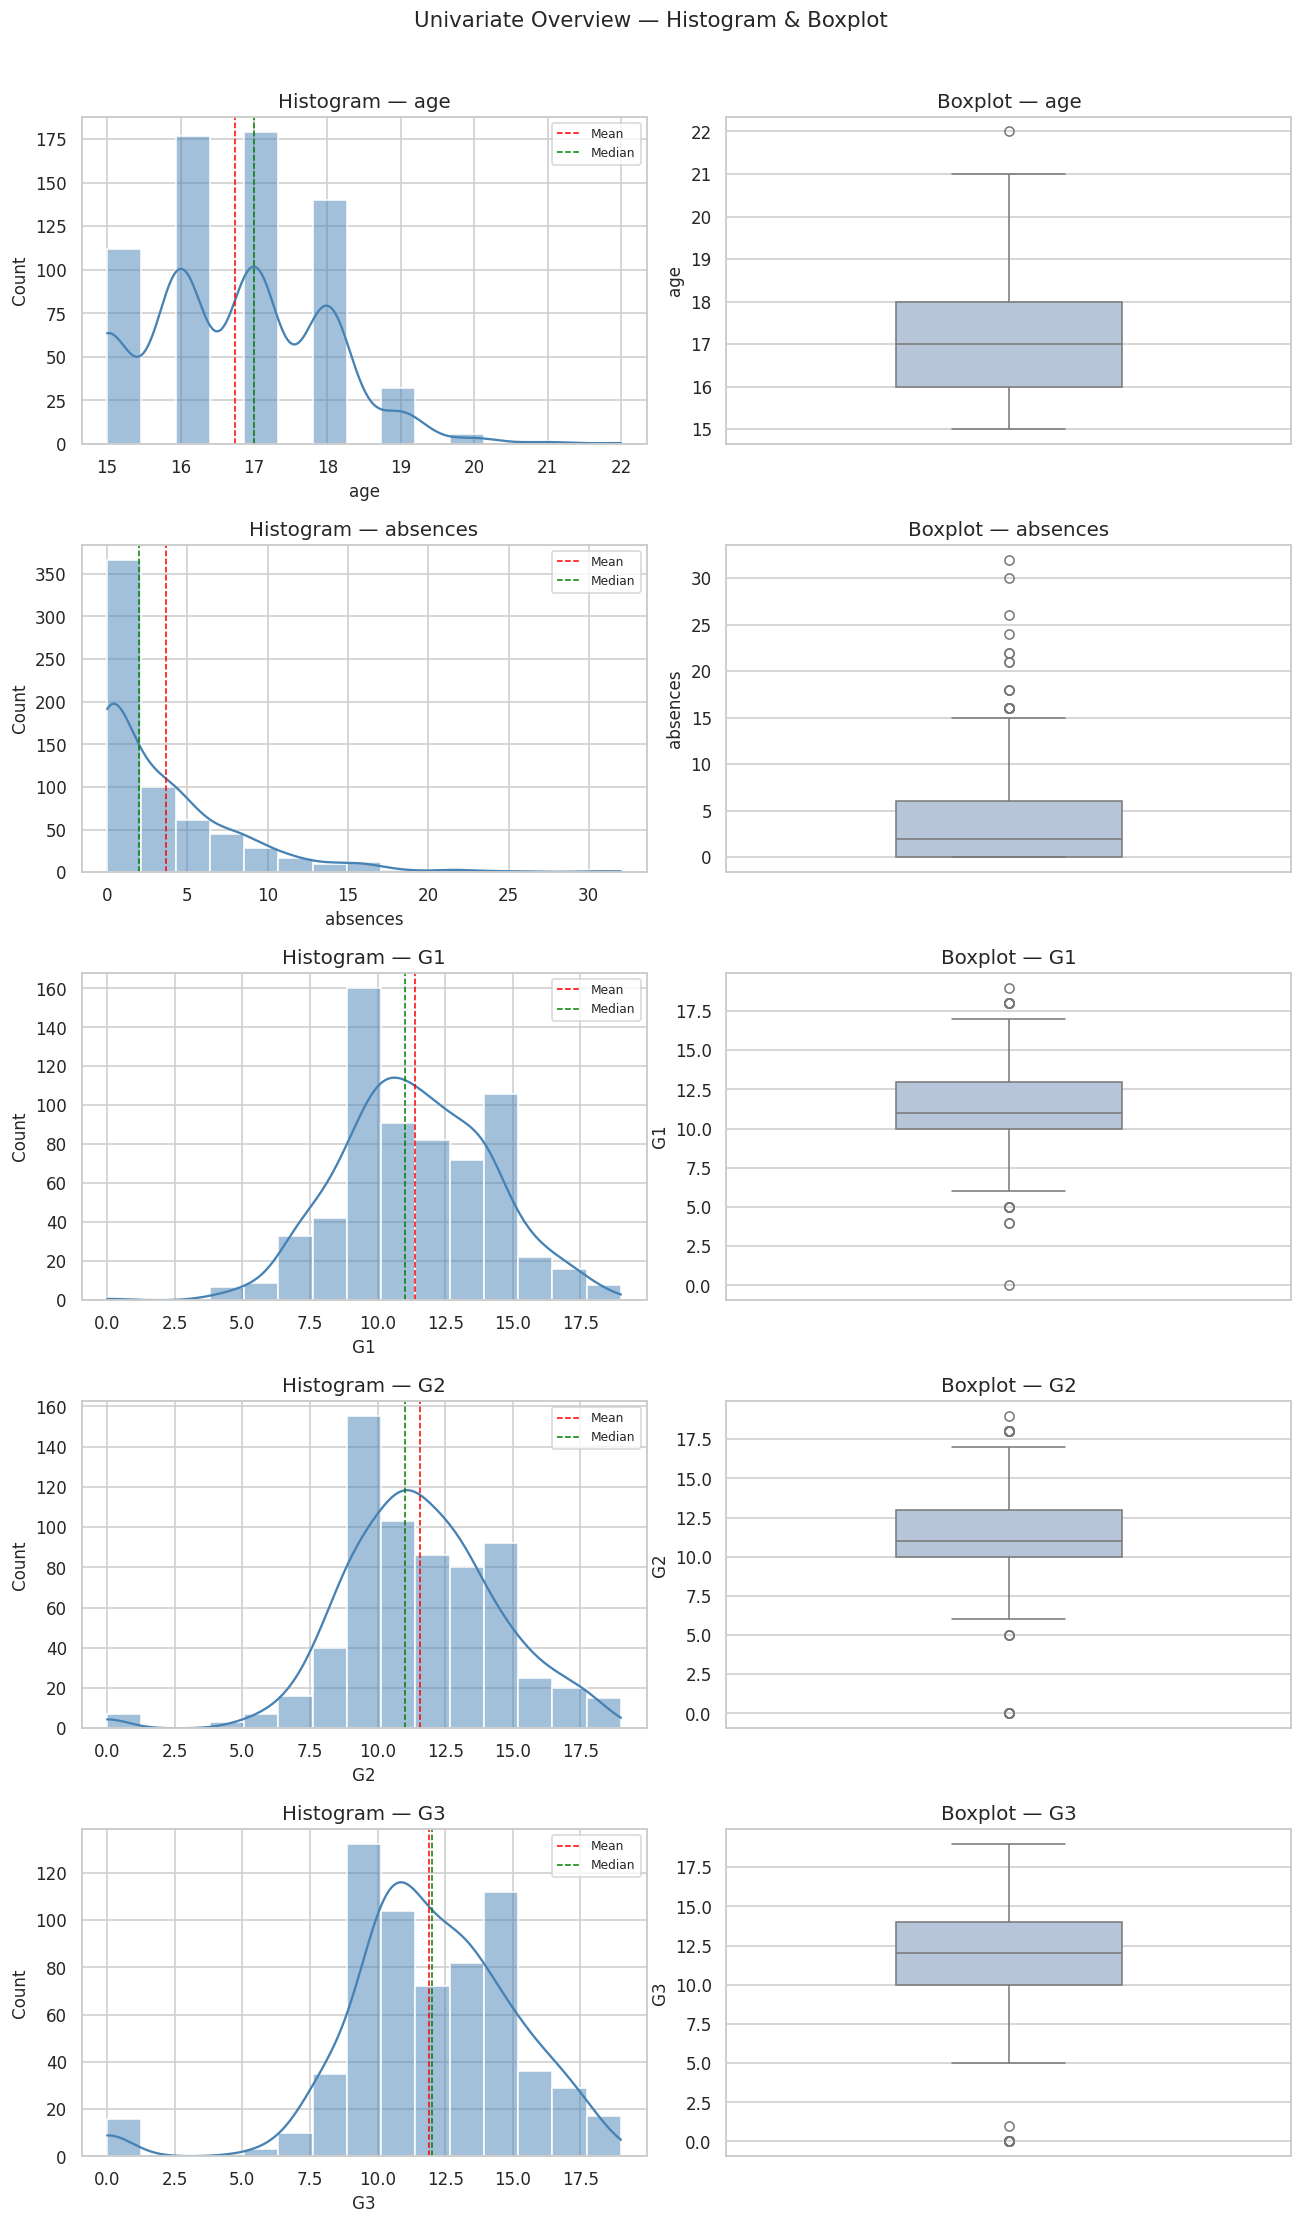

In [20]:
# ── 6.1  Side-by-side comparison across all numerical columns ─────────

num_cols = ["age", "absences", "G1", "G2", "G3"]

fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 4 * len(num_cols)))

for i, col in enumerate(num_cols):
    # Histogram
    sns.histplot(df[col], kde=True, bins=15, ax=axes[i][0], color="steelblue")
    axes[i][0].set_title(f"Histogram — {col}")
    axes[i][0].axvline(df[col].mean(),   color="red",   linestyle="--", linewidth=1, label="Mean")
    axes[i][0].axvline(df[col].median(), color="green", linestyle="--", linewidth=1, label="Median")
    axes[i][0].legend(fontsize=8)

    # Boxplot
    sns.boxplot(y=df[col], ax=axes[i][1], color="lightsteelblue", width=0.4)
    axes[i][1].set_title(f"Boxplot — {col}")

plt.suptitle("Univariate Overview — Histogram & Boxplot", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Exercise 4 — Final Challenge
Pick **any two columns** from the dataset — one numerical and one categorical.  
For each:
1. Compute the appropriate descriptive statistics
2. Produce the most suitable plot
3. Write 2–3 sentences interpreting what you see

```python
# Your code here
```

In [ ]:
#  Your answer here


---
## Summary

| Concept | Key Takeaway |
|---|---|
| **Central Tendency** | Mean is sensitive to outliers; median is robust |
| **Spread** | Std and IQR measure variability; IQR is robust |
| **Shape** | Skewness tells you if the distribution is symmetric |
| **Histogram** | Shows distribution shape and frequency |
| **Boxplot** | Shows spread, median, and outliers in one plot |
| **KDE** | Smooth estimate of the distribution |
| **Violin** | KDE + Boxplot combined |
| **ECDF** | Reads off any percentile directly |
| **Bar chart** | Frequency of categorical values |
| **Pie chart** | Proportions for low-cardinality variables |

---
### Take-Home Assignment
Choose a **new dataset** from Kaggle or UCI.  
For **three columns** of your choice (at least one categorical and one continuous):
1. Run `univariate_profile()` or equivalent
2. Identify any skewness, outliers, or interesting patterns
3. Write a short paragraph (5–6 sentences) summarising your findings

**Bring your notebook to the next session. **

---
*Eötvös Loránd University (ELTE) · Faculty of Informatics · Introduction to Data Science*